In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv('laptop_prices.csv')

In [3]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD
0,16GB,2.1,HDD,30,77.768048,Space Gray,91,562.397622
1,8 GB,3.6,SSD,15,90.190981,Matte Black,2,951.058104
2,8GB,3.7,SSD,27,NaN,Silver,19,791.169031
3,16 GB,1.2,NVMe,38,71.654528,Matte Black,15,652.522101
4,16GB,1.9,SSD,19,82.978123,Matte Black,18,833.020998
...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.457104,Rose Gold,97,739.908114
1011,16 GB,1.5,NVMe,5,96.623883,Rose Gold,33,979.477500
1012,16 GB,4.1,NVMe,14,87.617018,Silver,36,1387.943396
1013,16GB,2.5,SSD,33,NaN,Rose Gold,18,839.771125


data cleaning and preprocessing workflow

In [4]:
#--Handle Missing Values (Null Values)
#.Remove rows/columns if necessary.
#.Fill missing values using mean, median, mode, etc.
#--Handle Duplicate Data
#.Remove duplicate records.
#--Handle Outliers
#.Detect and treat extreme values using IQR, Z-score, etc.
#--Handle Imbalanced Data (only for classification problems)
#.Use oversampling, undersampling, or techniques like SMOTE.
#--Convert Categorical Features to Numerical
#.Label Encoding
#.One-Hot Encoding
#--Feature Selection / Find Important Features
#.Remove irrelevant features.
#.Use correlation, feature importance, mutual information, etc.
#--Check Correlation
#.Find highly correlated features and remove redundancy if needed.
#--Feature Scaling
#.Standardization (Z-score scaling)
#.Normalization (Min-Max scaling)
#--Split the Data
#.Train set
#.Validation set (optional)
#.Test set

Check Null Values

In [5]:
data.isnull().sum()

RAM_GB                     0
Processor_Speed_GHz       51
Storage_Type               0
Age_Months                 0
Battery_Health_Percent    51
Color                      0
Brand_Popularity_Score     0
Price_USD                  0
dtype: int64

In [6]:
data['Processor_Speed_GHz'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2.1
1       3.6
2       3.7
3       1.2
4       1.9
       ... 
1010    4.0
1011    1.5
1012    4.1
1013    2.5
1014    1.7
Name: Processor_Speed_GHz, Length: 1015, dtype: float64>

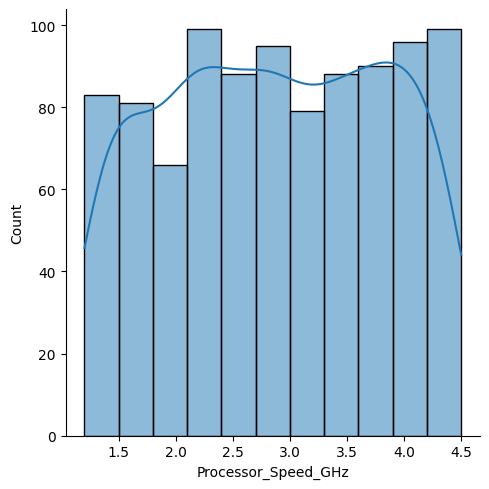

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.displot(data['Processor_Speed_GHz'],kde=True)
plt.show()
# the displot is uniform so we used mean to replace the null values 

In [8]:
#-0.5 to 0.5 → Approximately symmetric-mean
#-1 to -0.5 or 0.5 to 1 → Moderately skewed -median
#Less than -1 or Greater than 1 → Highly skewed -median 

In [9]:
data['Processor_Speed_GHz'].skew()
#the distribution of the feature Processor_Speed_GHz is symmetric and the skew value is -0.5 to 0.5 so we can use mean to fill the missing value 

np.float64(-0.034042927704070185)

In [10]:
mean_Processor_Speed=round(data['Processor_Speed_GHz'].mean(),1)
mean_Processor_Speed

np.float64(2.9)

In [11]:
data['Processor_Speed_GHz'].fillna(mean_Processor_Speed,inplace=True)

In [12]:
data.isnull().sum()

RAM_GB                     0
Processor_Speed_GHz        0
Storage_Type               0
Age_Months                 0
Battery_Health_Percent    51
Color                      0
Brand_Popularity_Score     0
Price_USD                  0
dtype: int64

In [13]:
data['Battery_Health_Percent'].value_counts()

Battery_Health_Percent
100.000000    39
97.369091      2
60.904328      2
84.789831      2
63.897471      2
              ..
96.213228      1
64.457104      1
96.623883      1
87.617018      1
92.641796      1
Name: count, Length: 913, dtype: int64

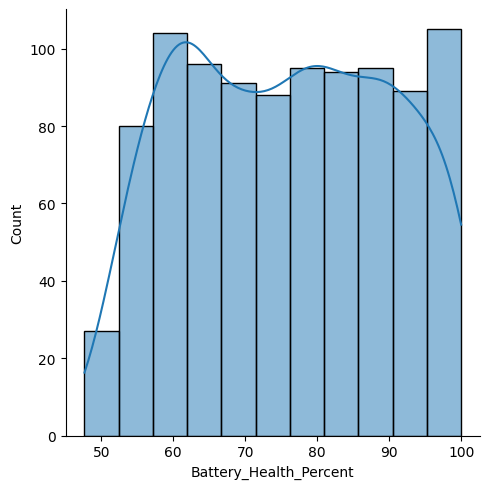

In [14]:
sns.displot(data['Battery_Health_Percent'],kde=True)
plt.show()

In [15]:
data['Battery_Health_Percent'].skew()
# now we can use mean value to fill the null value because Approximately symmetric betweeen -0.5 to 0.5

np.float64(0.023484711026219553)

In [16]:
mean_Battery_Health_Percent=data['Battery_Health_Percent'].mean()
mean_Battery_Health_Percent

np.float64(75.86895190242909)

In [17]:
data['Battery_Health_Percent'].fillna(mean_Battery_Health_Percent,inplace=True)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\1949409981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Battery_Health_Percent'].fillna(mean_Battery_Health_Percent,inplace=True)


In [18]:
data.isnull().sum()

RAM_GB                    0
Processor_Speed_GHz       0
Storage_Type              0
Age_Months                0
Battery_Health_Percent    0
Color                     0
Brand_Popularity_Score    0
Price_USD                 0
dtype: int64

remove duplicate records

In [19]:
# because the row  is appear multiple the thinks the duplicate record is more important
#The model may learn repeated examples too strongly-Overfitting Risk
data_duplicate=data[data.duplicated(keep=False)]
print(data_duplicate)

     RAM_GB  Processor_Speed_GHz Storage_Type  Age_Months  \
14     8 GB                  2.4         NVMe          17   
23      8GB                  1.4         NVMe           4   
69      8GB                  4.4          SSD          49   
124    8 GB                  2.4         NVMe          17   
125    8 GB                  3.5          HDD          59   
143   32 GB                  3.2          SSD          39   
163    4 GB                  3.1          SSD          20   
180    8 GB                  2.9         NVMe          36   
228     8GB                  4.4          SSD          49   
245    16GB                  2.2          SSD          52   
250     8GB                  1.4         NVMe           4   
300    32GB                  2.2          SSD          51   
346    4 GB                  3.1          SSD          20   
349    8 GB                  2.1          SSD           0   
391    16GB                  2.2          SSD          52   
404    8 GB             

In [20]:
data=data.drop_duplicates()

In [21]:
data.duplicated().sum()

np.int64(0)

Check Outliers Using Boxplot

In [22]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD
0,16GB,2.1,HDD,30,77.768048,Space Gray,91,562.397622
1,8 GB,3.6,SSD,15,90.190981,Matte Black,2,951.058104
2,8GB,3.7,SSD,27,75.868952,Silver,19,791.169031
3,16 GB,1.2,NVMe,38,71.654528,Matte Black,15,652.522101
4,16GB,1.9,SSD,19,82.978123,Matte Black,18,833.020998
...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.457104,Rose Gold,97,739.908114
1011,16 GB,1.5,NVMe,5,96.623883,Rose Gold,33,979.477500
1012,16 GB,4.1,NVMe,14,87.617018,Silver,36,1387.943396
1013,16GB,2.5,SSD,33,75.868952,Rose Gold,18,839.771125


In [23]:
data['Price_USD']=(data['Price_USD']*98).round(2)
data['Battery_Health_Percent']=data['Battery_Health_Percent'].round(2)
data=data[data['Age_Months']<=72]


C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\28854591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Price_USD']=(data['Price_USD']*98).round(2)
C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\28854591.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Battery_Health_Percent']=data['Battery_Health_Percent'].round(2)


In [24]:
data['Price_USD']=(data['Price_USD']/98).round(2)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\33473708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Price_USD']=(data['Price_USD']/98).round(2)


In [25]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD
0,16GB,2.1,HDD,30,77.77,Space Gray,91,562.40
1,8 GB,3.6,SSD,15,90.19,Matte Black,2,951.06
2,8GB,3.7,SSD,27,75.87,Silver,19,791.17
3,16 GB,1.2,NVMe,38,71.65,Matte Black,15,652.52
4,16GB,1.9,SSD,19,82.98,Matte Black,18,833.02
...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.46,Rose Gold,97,739.91
1011,16 GB,1.5,NVMe,5,96.62,Rose Gold,33,979.48
1012,16 GB,4.1,NVMe,14,87.62,Silver,36,1387.94
1013,16GB,2.5,SSD,33,75.87,Rose Gold,18,839.77


In [26]:
age_divied=data['Age_Months']/100
battery_divied=data['Battery_Health_Percent']/100
price_inr=data['Price_USD']*83.5
data['price']=(data['Price_USD']*83.5)*(1-age_divied)*(battery_divied)



C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\3495342847.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price']=(data['Price_USD']*83.5)*(1-age_divied)*(battery_divied)


In [27]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD,price
0,16GB,2.1,HDD,30,77.77,Space Gray,91,562.40,25564.772156
1,8 GB,3.6,SSD,15,90.19,Matte Black,2,951.06,60879.587969
2,8GB,3.7,SSD,27,75.87,Silver,19,791.17,36588.889688
3,16 GB,1.2,NVMe,38,71.65,Matte Black,15,652.52,24204.058127
4,16GB,1.9,SSD,19,82.98,Matte Black,18,833.02,46752.017129
...,...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.46,Rose Gold,97,739.91,23098.494102
1011,16 GB,1.5,NVMe,5,96.62,Rose Gold,33,979.48,75071.083916
1012,16 GB,4.1,NVMe,14,87.62,Silver,36,1387.94,87329.076541
1013,16GB,2.5,SSD,33,75.87,Rose Gold,18,839.77,35644.433602


In [28]:
data['price']=data['price'].round(2)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\2458692347.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price']=data['price'].round(2)


In [29]:
data1=pd.read_csv('laptop_prices.csv')

In [30]:
age_divied=data['Age_Months']/100
battery_divied=data['Battery_Health_Percent']/100
price_inr=data1['Price_USD']*83.5
age_factor=(1- age_divied).clip(lower=0.20)
data['price_new']=price_inr*age_factor*battery_divied



C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\2238692883.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price_new']=price_inr*age_factor*battery_divied


In [31]:
data['price_new']=data['price_new'].round(2)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\2210678669.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price_new']=data['price_new'].round(2)


In [32]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD,price,price_new
0,16GB,2.1,HDD,30,77.77,Space Gray,91,562.40,25564.77,25564.66
1,8 GB,3.6,SSD,15,90.19,Matte Black,2,951.06,60879.59,60879.47
2,8GB,3.7,SSD,27,75.87,Silver,19,791.17,36588.89,36588.84
3,16 GB,1.2,NVMe,38,71.65,Matte Black,15,652.52,24204.06,24204.14
4,16GB,1.9,SSD,19,82.98,Matte Black,18,833.02,46752.02,46752.07
...,...,...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.46,Rose Gold,97,739.91,23098.49,23098.44
1011,16 GB,1.5,NVMe,5,96.62,Rose Gold,33,979.48,75071.08,75070.89
1012,16 GB,4.1,NVMe,14,87.62,Silver,36,1387.94,87329.08,87329.29
1013,16GB,2.5,SSD,33,75.87,Rose Gold,18,839.77,35644.43,35644.48


In [33]:
data[data['price_new']>5000*83]

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD,price,price_new
304,8GB,2.8,HDD,19,82.30,Rose Gold,47,120000.0,6679632.60,6679632.60
426,32GB,2.6,SSD,40,62.79,Rose Gold,12,110000.0,3460356.90,3460356.90
763,16GB,1.8,SSD,58,54.81,Rose Gold,82,95000.0,1826077.37,1826077.37
801,8GB,1.6,SSD,31,69.18,Silver,8,88000.0,3507509.02,3507509.02
823,16 GB,3.5,SSD,3,96.42,Silver,74,75000.0,5857153.43,5857153.43


In [34]:
data1[data1['Price_USD']>5000]

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD
304,8GB,2.8,HDD,19,82.299092,Rose Gold,47,120000.0
426,32GB,2.6,SSD,40,62.789551,Rose Gold,12,110000.0
763,16GB,1.8,SSD,58,54.809574,Rose Gold,82,95000.0
801,8GB,1.6,SSD,31,69.179664,Silver,8,88000.0
823,16 GB,3.5,SSD,3,96.415113,Silver,74,75000.0


In [35]:
data=data[data['price_new']<5000*83]

In [36]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD,price,price_new
0,16GB,2.1,HDD,30,77.77,Space Gray,91,562.40,25564.77,25564.66
1,8 GB,3.6,SSD,15,90.19,Matte Black,2,951.06,60879.59,60879.47
2,8GB,3.7,SSD,27,75.87,Silver,19,791.17,36588.89,36588.84
3,16 GB,1.2,NVMe,38,71.65,Matte Black,15,652.52,24204.06,24204.14
4,16GB,1.9,SSD,19,82.98,Matte Black,18,833.02,46752.02,46752.07
...,...,...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.46,Rose Gold,97,739.91,23098.49,23098.44
1011,16 GB,1.5,NVMe,5,96.62,Rose Gold,33,979.48,75071.08,75070.89
1012,16 GB,4.1,NVMe,14,87.62,Silver,36,1387.94,87329.08,87329.29
1013,16GB,2.5,SSD,33,75.87,Rose Gold,18,839.77,35644.43,35644.48


In [37]:
data.drop('price_new',axis=1,inplace=True)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\3376370024.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('price_new',axis=1,inplace=True)


In [38]:
data.describe()

,Processor_Speed_GHz,Age_Months,Battery_Health_Percent,Brand_Popularity_Score,Price_USD,price
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,2.867172,30.063636,75.878162,50.113131,832.176768,41301.311253
std,0.934380,17.566600,13.927473,28.361228,407.428177,29936.048445
min,1.200000,0.000000,47.680000,1.000000,120.000000,2115.140000
25%,2.100000,15.000000,63.705000,25.000000,557.402500,18248.660000
50%,2.900000,29.000000,75.870000,51.000000,775.420000,33847.860000
75%,3.700000,46.000000,87.640000,75.000000,1029.385000,58993.412500
max,4.500000,59.000000,100.000000,99.000000,2634.420000,217774.330000


In [39]:
data['price']=data['price'].clip(upper=91300)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\3153807020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price']=data['price'].clip(upper=91300)


In [40]:
data['price'].describe()

count      990.000000
mean     39688.600707
std      25778.797047
min       2115.140000
25%      18248.660000
50%      33847.860000
75%      58993.412500
max      91300.000000
Name: price, dtype: float64

In [41]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD,price
0,16GB,2.1,HDD,30,77.77,Space Gray,91,562.40,25564.77
1,8 GB,3.6,SSD,15,90.19,Matte Black,2,951.06,60879.59
2,8GB,3.7,SSD,27,75.87,Silver,19,791.17,36588.89
3,16 GB,1.2,NVMe,38,71.65,Matte Black,15,652.52,24204.06
4,16GB,1.9,SSD,19,82.98,Matte Black,18,833.02,46752.02
...,...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.46,Rose Gold,97,739.91,23098.49
1011,16 GB,1.5,NVMe,5,96.62,Rose Gold,33,979.48,75071.08
1012,16 GB,4.1,NVMe,14,87.62,Silver,36,1387.94,87329.08
1013,16GB,2.5,SSD,33,75.87,Rose Gold,18,839.77,35644.43


In [42]:
data.drop('Price_USD',axis=1,inplace=True)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\4079404216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Price_USD',axis=1,inplace=True)


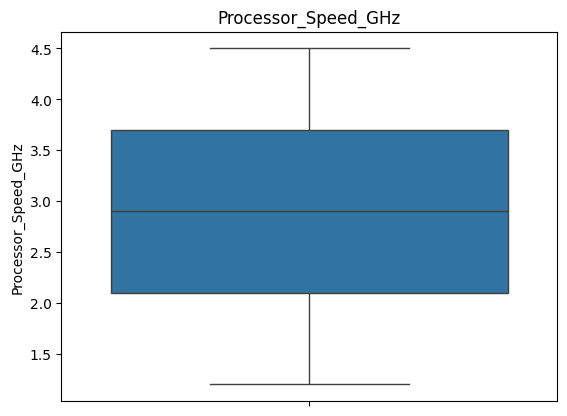

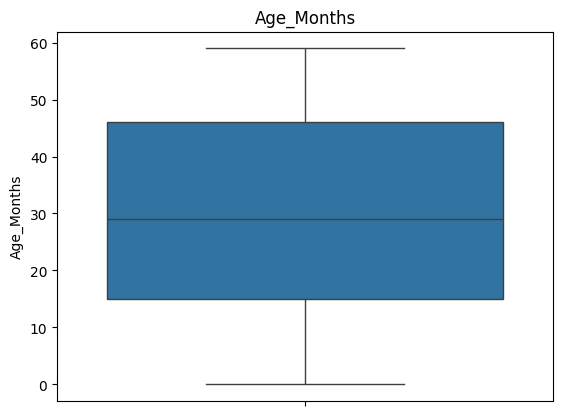

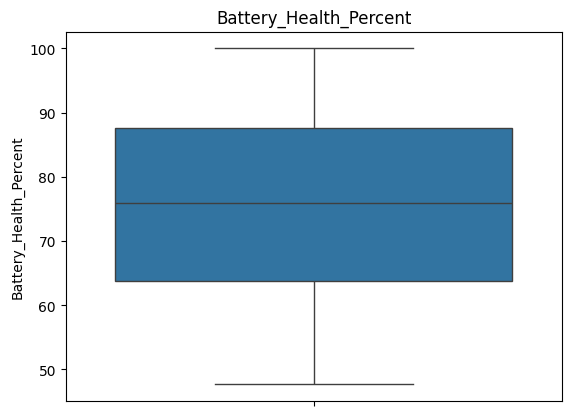

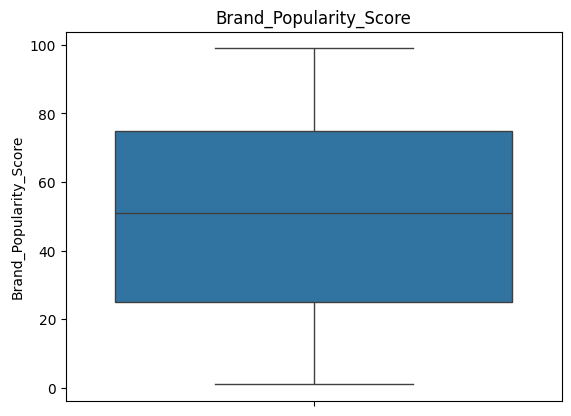

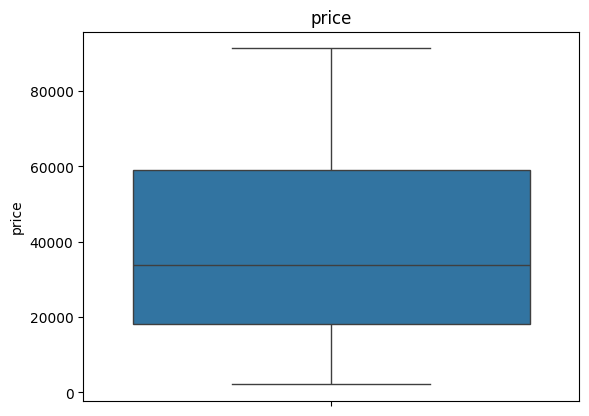

In [43]:
num_col=data.select_dtypes(include=['int64','float64']).columns
for col in num_col:
  sns.boxplot(data[col])
  plt.title(col)
  plt.show()

Handle Imbalanced Data

In [44]:
data['Color'].value_counts()

Color
Silver         264
Space Gray     261
Matte Black    233
Rose Gold      232
Name: count, dtype: int64

In [45]:
data['RAM_GB'].value_counts()

RAM_GB
8 GB     206
8GB      184
16GB     141
16 GB    141
4GB       87
4 GB      79
32 GB     76
32GB      54
64 GB     12
64GB      10
Name: count, dtype: int64

In [46]:
data['RAM_GB']=data['RAM_GB'].str.replace(' ','')

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\994215970.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RAM_GB']=data['RAM_GB'].str.replace(' ','')


In [47]:
data['RAM_GB'].value_counts()

RAM_GB
8GB     390
16GB    282
4GB     166
32GB    130
64GB     22
Name: count, dtype: int64

In [48]:
data['Storage_Type'].value_counts()

Storage_Type
SSD     487
NVMe    297
HDD     206
Name: count, dtype: int64

In [49]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,price
0,16GB,2.1,HDD,30,77.77,Space Gray,91,25564.77
1,8GB,3.6,SSD,15,90.19,Matte Black,2,60879.59
2,8GB,3.7,SSD,27,75.87,Silver,19,36588.89
3,16GB,1.2,NVMe,38,71.65,Matte Black,15,24204.06
4,16GB,1.9,SSD,19,82.98,Matte Black,18,46752.02
...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.46,Rose Gold,97,23098.49
1011,16GB,1.5,NVMe,5,96.62,Rose Gold,33,75071.08
1012,16GB,4.1,NVMe,14,87.62,Silver,36,87329.08
1013,16GB,2.5,SSD,33,75.87,Rose Gold,18,35644.43


Convert Categorical Features to Numerical

In [50]:
#Label Encoding (For Ordinal Data: Where Order Matters)
#One-Hot Encoding (For Nominal Data: Where Order Does NOT Matter)


In [50]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['RAM_GB']=le.fit_transform(data['RAM_GB'])
storage_dummies=pd.get_dummies(data['Storage_Type'],prefix='Storage_Type')
color_dummies=pd.get_dummies(data['Color'],prefix='color')
data = pd.concat([data.drop(['Storage_Type','Color'], axis=1),storage_dummies, color_dummies], axis=1)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_12104\2079314184.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RAM_GB']=le.fit_transform(data['RAM_GB'])


In [51]:
storage_dummies.columns

Index(['Storage_Type_HDD', 'Storage_Type_NVMe', 'Storage_Type_SSD'], dtype='object')

In [52]:
data

,RAM_GB,Processor_Speed_GHz,Age_Months,Battery_Health_Percent,Brand_Popularity_Score,price,Storage_Type_HDD,Storage_Type_NVMe,Storage_Type_SSD,color_Matte Black,color_Rose Gold,color_Silver,color_Space Gray
0,0,2.1,30,77.77,91,25564.77,True,False,False,False,False,False,True
1,4,3.6,15,90.19,2,60879.59,False,False,True,True,False,False,False
2,4,3.7,27,75.87,19,36588.89,False,False,True,False,False,True,False
3,0,1.2,38,71.65,15,24204.06,False,True,False,True,False,False,False
4,0,1.9,19,82.98,18,46752.02,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,4,4.0,42,64.46,97,23098.49,True,False,False,False,True,False,False
1011,0,1.5,5,96.62,33,75071.08,False,True,False,False,True,False,False
1012,0,4.1,14,87.62,36,87329.08,False,True,False,False,False,True,False
1013,0,2.5,33,75.87,18,35644.43,False,False,True,False,True,False,False


In [53]:
data

,RAM_GB,Processor_Speed_GHz,Age_Months,Battery_Health_Percent,Brand_Popularity_Score,price,Storage_Type_HDD,Storage_Type_NVMe,Storage_Type_SSD,color_Matte Black,color_Rose Gold,color_Silver,color_Space Gray
0,0,2.1,30,77.77,91,25564.77,True,False,False,False,False,False,True
1,4,3.6,15,90.19,2,60879.59,False,False,True,True,False,False,False
2,4,3.7,27,75.87,19,36588.89,False,False,True,False,False,True,False
3,0,1.2,38,71.65,15,24204.06,False,True,False,True,False,False,False
4,0,1.9,19,82.98,18,46752.02,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,4,4.0,42,64.46,97,23098.49,True,False,False,False,True,False,False
1011,0,1.5,5,96.62,33,75071.08,False,True,False,False,True,False,False
1012,0,4.1,14,87.62,36,87329.08,False,True,False,False,False,True,False
1013,0,2.5,33,75.87,18,35644.43,False,False,True,False,True,False,False


In [54]:
data.columns

Index(['RAM_GB', 'Processor_Speed_GHz', 'Age_Months', 'Battery_Health_Percent',
       'Brand_Popularity_Score', 'price', 'Storage_Type_HDD',
       'Storage_Type_NVMe', 'Storage_Type_SSD', 'color_Matte Black',
       'color_Rose Gold', 'color_Silver', 'color_Space Gray'],
      dtype='object')

In [55]:
data=data.astype('int')

In [56]:
data

,RAM_GB,Processor_Speed_GHz,Age_Months,Battery_Health_Percent,Brand_Popularity_Score,price,Storage_Type_HDD,Storage_Type_NVMe,Storage_Type_SSD,color_Matte Black,color_Rose Gold,color_Silver,color_Space Gray
0,0,2,30,77,91,25564,1,0,0,0,0,0,1
1,4,3,15,90,2,60879,0,0,1,1,0,0,0
2,4,3,27,75,19,36588,0,0,1,0,0,1,0
3,0,1,38,71,15,24204,0,1,0,1,0,0,0
4,0,1,19,82,18,46752,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,4,4,42,64,97,23098,1,0,0,0,1,0,0
1011,0,1,5,96,33,75071,0,1,0,0,1,0,0
1012,0,4,14,87,36,87329,0,1,0,0,0,1,0
1013,0,2,33,75,18,35644,0,0,1,0,1,0,0


In [57]:
data.columns

Index(['RAM_GB', 'Processor_Speed_GHz', 'Age_Months', 'Battery_Health_Percent',
       'Brand_Popularity_Score', 'price', 'Storage_Type_HDD',
       'Storage_Type_NVMe', 'Storage_Type_SSD', 'color_Matte Black',
       'color_Rose Gold', 'color_Silver', 'color_Space Gray'],
      dtype='object')

In [58]:
x=data.drop('price',axis=1)
y=data['price']

In [60]:
x.columns

Index(['RAM_GB', 'Processor_Speed_GHz', 'Age_Months', 'Battery_Health_Percent',
       'Brand_Popularity_Score', 'Storage_Type_HDD', 'Storage_Type_NVMe',
       'Storage_Type_SSD', 'color_Matte Black', 'color_Rose Gold',
       'color_Silver', 'color_Space Gray'],
      dtype='object')

In [61]:
y

0       25564
1       60879
2       36588
3       24204
4       46752
        ...  
1010    23098
1011    75071
1012    87329
1013    35644
1014    31100
Name: price, Length: 990, dtype: int64

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [63]:
x_train

,RAM_GB,Processor_Speed_GHz,Age_Months,Battery_Health_Percent,Brand_Popularity_Score,Storage_Type_HDD,Storage_Type_NVMe,Storage_Type_SSD,color_Matte Black,color_Rose Gold,color_Silver,color_Space Gray
770,0,3,16,83,58,0,0,1,0,0,1,0
217,2,4,38,71,19,1,0,0,0,0,1,0
298,4,2,5,90,45,0,0,1,0,0,1,0
49,0,1,42,66,40,0,0,1,0,1,0,0
736,2,2,22,83,21,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,0,2,2,93,75,1,0,0,0,0,1,0
274,0,4,42,66,23,0,0,1,0,0,0,1
882,0,2,15,89,80,0,0,1,0,1,0,0
445,2,4,46,64,35,0,0,1,1,0,0,0


In [64]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
lr.score(x_train,y_train)

0.7839433847854909

In [66]:
lr.score(x_test,y_test)

0.7813202285076737

In [73]:
lr.predict(x_test[1:2])

array([48444.49247724])

In [74]:
y_test[1:2]

336    42736
Name: price, dtype: int64

In [75]:
x_test[1:2]

,RAM_GB,Processor_Speed_GHz,Age_Months,Battery_Health_Percent,Brand_Popularity_Score,Storage_Type_HDD,Storage_Type_NVMe,Storage_Type_SSD,color_Matte Black,color_Rose Gold,color_Silver,color_Space Gray
336,4,2,19,84,40,0,1,0,0,1,0,0


In [76]:
y_test[1:2]

336    42736
Name: price, dtype: int64